In [3]:
import numpy as np
import matplotlib.pyplot as plt
import utils_FaIR_JAX
import pickle

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
emis_dict_CS3_JAX.keys()

dict_keys(['AA', 'CT', 'historical'])

In [37]:
agents = ['CO2']
emis_dict_tier1_JAX, emis_dict_tier2_JAX, emis_dict_DECK_JAX, emis_dict_CS3_JAX = utils_FaIR_JAX.generate_JAX_data(agents, CS3=True)
emis_dict_all_JAX = emis_dict_tier1_JAX | emis_dict_tier2_JAX | emis_dict_DECK_JAX | emis_dict_CS3_JAX

needs_hist = ['H-ext', 'M', 'ML', 'L', 'VLLO-ext', 'VLHO', 'H-ext-OS', 'M-ext', 'ML-ext', 'L-ext', 'VLHO-ext','AA','CT']

In [49]:
def write_emissions_file(co2_array, filepath, hist=None):
    if hist is not None:
        co2_array = np.concatenate([hist, co2_array])

    with open(filepath, 'w') as f:
        # Headers written verbatim as requested
        f.write("UNITS:  GtC/yr  GtCO2/yr\n")
        f.write("YEARS   FossilCO2\n")

        # Iterate through the array with a 1-based index for the year
        for year, co2 in enumerate(co2_array, 1):
            # Convert GtCO2 to GtC (ratio of atomic mass 12/44)
            carbon = co2 * (12.0 / 44.0)

            # Write year, calculated Carbon, and original CO2 with source-matched spacing
            f.write(f"{year:4d}{carbon:18.6f}{co2:18.6f}\n")

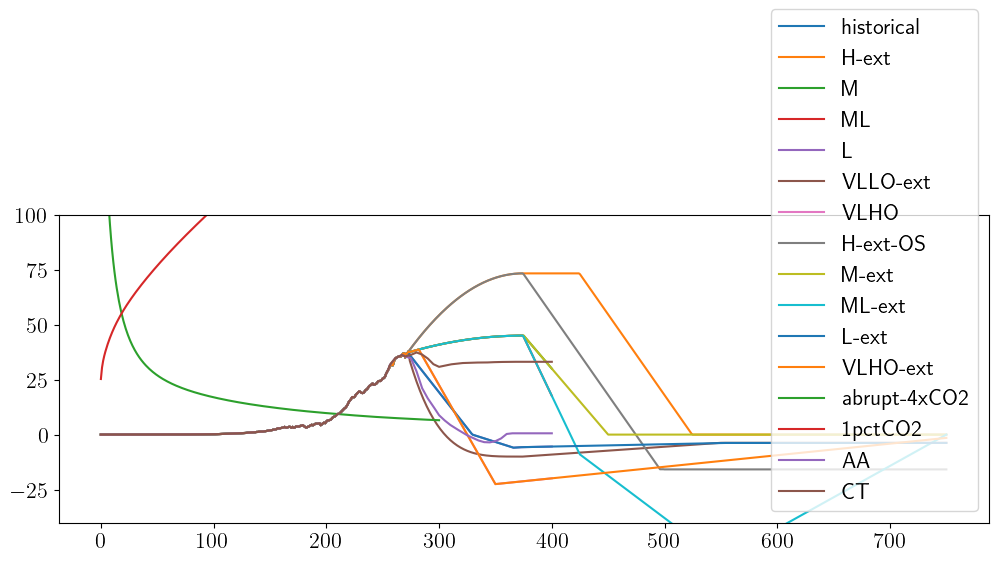

In [50]:
for scen in emis_dict_all_JAX.keys():
  filepath = f'data/MESM/emis_driven/MESM_inputs/{scen}_emis.txt'
  co2_array = emis_dict_all_JAX[scen][0,:]
  if scen in needs_hist:
    if scen in ['AA','CT']:
      hist = emis_dict_CS3_JAX['historical'][0,:]
    else:
      hist = emis_dict_tier1_JAX['historical'][0,:]
    plt.plot(np.concat([hist, co2_array]), label=scen)
  else:
    hist = None
    plt.plot(co2_array, label=scen)

  write_emissions_file(co2_array, filepath, hist=hist)
  plt.ylim([-40, 100])
  plt.legend()

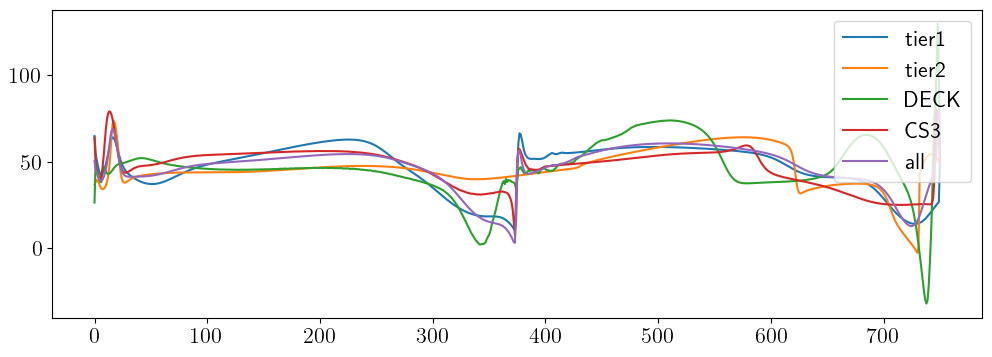

In [51]:

groups = ['tier1','tier2','DECK','CS3','all']

for group in groups:
  opt_path = f"checkpoints/co2/inverse_constant_{group}_co2_only_MESM.pkl"
  filepath = f'data/MESM/emis_driven/MESM_inputs/opt_{group}_emis.txt'
  with open(opt_path, "rb") as f:
    res = pickle.load(f)
  co2_array = res['U_traj'][-1]['CO2']

  plt.plot(co2_array, label=group)
  write_emissions_file(co2_array, filepath, hist=None)
plt.legend()